In [187]:
pip install chart_studio

In [188]:
import numpy as np
import pandas as pd
#import plotly.plotly as py
import chart_studio.plotly as py
#from plotly.offline import init_notebook_mode,iplot
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
import plotly.graph_objects as go
from plotly import tools
import warnings
warnings.filterwarnings("ignore")

***Nesta base, examinamos os tweets de pessoas com opinião política democrática e republicana.***

In [189]:
#Carregando a base de Tweets Democratas e Republicanos
tweets_dem_rep = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Tweet/ExtractedTweets.csv')
base_tweets.head(10)

,Party,Handle,Tweet
0,Democrat,RepDarrenSoto,"Today, Senate Dems vote to #SaveTheInternet. P..."
1,Democrat,RepDarrenSoto,RT @WinterHavenSun: Winter Haven resident / Al...
2,Democrat,RepDarrenSoto,RT @NBCLatino: .@RepDarrenSoto noted that Hurr...
3,Democrat,RepDarrenSoto,RT @NALCABPolicy: Meeting with @RepDarrenSoto ...
4,Democrat,RepDarrenSoto,RT @Vegalteno: Hurricane season starts on June...
5,Democrat,RepDarrenSoto,RT @EmgageActionFL: Thank you to all who came ...
6,Democrat,RepDarrenSoto,Hurricane Maria left approx $90 billion in dam...
7,Democrat,RepDarrenSoto,RT @Tharryry: I am delighted that @RepDarrenSo...
8,Democrat,RepDarrenSoto,RT @HispanicCaucus: Trump's anti-immigrant pol...
9,Democrat,RepDarrenSoto,RT @RepStephMurphy: Great joining @WeAreUnidos...


In [190]:
tweets_dem_rep.Party.value_counts()

Republican    44392
Democrat      42068
Name: Party, dtype: int64

In [191]:
tweets_handles = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Tweet/TwitterHandles.csv')
tweets_handles.head(10)

,Party,Name,Handle,AvatarURL
0,Democrat,US Rep. Darren Soto,RepDarrenSoto,https://pbs.twimg.com/profile_images/824454906...
1,Democrat,Rep. Jacky Rosen,RepJackyRosen,https://pbs.twimg.com/profile_images/837772241...
2,Democrat,US Rep. Al Lawson Jr,RepAlLawsonJr,https://pbs.twimg.com/profile_images/818493713...
3,Democrat,Adriano Espaillat,RepEspaillat,https://pbs.twimg.com/profile_images/827580972...
4,Democrat,US Rep. Darren Soto,RepDarrenSoto,https://pbs.twimg.com/profile_images/824454906...
5,Democrat,Rep. Jacky Rosen,RepJackyRosen,https://pbs.twimg.com/profile_images/837772241...
6,Democrat,US Rep. Al Lawson Jr,RepAlLawsonJr,https://pbs.twimg.com/profile_images/818493713...
7,Democrat,Adriano Espaillat,RepEspaillat,https://pbs.twimg.com/profile_images/827580972...
8,Democrat,Rep. Blunt Rochester,RepBRochester,https://pbs.twimg.com/profile_images/912673706...
9,Democrat,Nanette D. Barragán,RepBarragan,https://pbs.twimg.com/profile_images/978337845...


In [192]:
tweets_handles.Party.value_counts()

Republican    24
Democrat      24
Name: Party, dtype: int64

# **E o primeiro tweet é:**

In [193]:
tweets_dem_rep.Tweet[0]

'Today, Senate Dems vote to #SaveTheInternet. Proud to support similar #NetNeutrality legislation here in the House… https://t.co/n3tggDLU1L'

# **1- LIMPEZA DE DADOS**

**Antes de iniciar a análise, devemos remover objetos como @, rt, html, # etc.**

In [194]:
import re
import nltk
from nltk.corpus import stopwords
import nltk as nlp
stopwords = stopwords.words('english')
#adicione alguma palavra desnecessária à lista de stopwords
stopwords.append("rt")
stopwords.append("u")
stopwords.append("amp")
stopwords.append("w")
stopwords.append("th")

In [195]:
#Criamos 2 classes diferentes como democratas e republicanas
democrat=tweets_dem_rep[tweets_dem_rep.Party=="Democrat"]
republican=tweets_dem_rep[tweets_dem_rep.Party=="Republican"]

In [196]:
#Limpeza de Tweets do partido democrata 
democrat_list=[]
for d in democrat.Tweet:
    d=re.sub(r'http\S+', '', d) #remover links
    d=re.sub("[^a-zA-Z]", " ", d) #remove todos os caracteres, exceto letras
    d=d.lower() #converter todas as palavras em minúsculas
    d=nltk.word_tokenize(d) #dividir frases em palavras
    d=[word for word in d if not word in set(stopwords)] #adicione à lista de palavras irrelevantes se palavras desnecessárias.
    lemma=nlp.WordNetLemmatizer() 
    d=[lemma.lemmatize(word) for word in d] #identifique a forma correta da palavra no dicionário
    d=" ".join(d)
    democrat_list.append(d) #acrescentar palavras à lista

In [197]:
#Limpeza de Tweets do partido republicano
republican_list=[]
for r in republican.Tweet:
    r=re.sub(r'http\S+', '', r)#remover links
    r=re.sub("[^a-zA-Z]", " ", r)#remove todos os caracteres, exceto letras
    r=r.lower()#converter todas as palavras em minúsculas
    r=nltk.word_tokenize(r)#dividir frases em palavras
    r=[word for word in r if not word in set(stopwords)]#adicione à lista de palavras irrelevantes se palavras desnecessárias.
    lemma=nlp.WordNetLemmatizer()
    r=[lemma.lemmatize(word) for word in r]#identifique a forma correta da palavra no dicionário
    r=" ".join(r)
    republican_list.append(r)#acrescentar palavras à lista

### **Agora nossas listas são as seguintes**

In [198]:
#primeiros 5 tweets da lista
democrat_list[0:5]

['today senate dems vote savetheinternet proud support similar netneutrality legislation house',
 'winterhavensun winter resident alta vista teacher one several recognized repdarrensoto national teacher apprecia',
 'nbclatino repdarrensoto noted hurricane maria left approximately billion damage congress allocated',
 'nalcabpolicy meeting repdarrensoto thanks taking time meet latinoleader ed marucci guzman nalcabpolicy',
 'vegalteno hurricane season start june st puerto rico readiness well pwr puertorico repdarrensoto espaillatny']

In [199]:
#primeiros 5 tweets da lista
republican_list[0:5]

['wastefulwednesday today introduced bill would eliminate global climate change initiative gc',
 'today honored heroic men woman law enforcement lost life line duty nati',
 'congressmanraja last week repralphnorman hosted briefing economic benefit solar energy production',
 'tegacaypd chief parker thankful receive recognition repralphnorman delivered mayor davidloneal national police',
 'visited sc highway patrol bring cupcake thank service honor']

###Revizando tweets palavra por palavra.
Dividindo as frases em palavras, remover caracteres de pontuação desnecessários.

In [200]:
democrat_tweets=str(democrat_list).split()
republican_tweets=str(republican_list).split()
democrat_tweets=[word.replace("'","") for word in democrat_tweets ]
democrat_tweets=[word.replace("[", "") for word in democrat_tweets ]
democrat_tweets=[word.replace("]","") for word in democrat_tweets ]
democrat_tweets=[word.replace(",", "") for word in democrat_tweets ]

republican_tweets=[word.replace("'","") for word in republican_tweets ]
republican_tweets=[word.replace("[", "") for word in republican_tweets ]
republican_tweets=[word.replace("]","") for word in republican_tweets ]
republican_tweets=[word.replace(",", "") for word in republican_tweets ]

**Agora vamos verificar o comprimento de duas listas.**

In [201]:
print("Democrat tweets word length:",len(democrat_tweets))
print("Republican tweets word length:",len(republican_tweets))

Democrat tweets word length: 443138
Republican tweets word length: 457293


**Existem 443138 palavras em tuítes democratas e 457293 palavras em tuítes republicanos.**

# **2- Frequência de Uso de Palavras pelas Partes**

In [237]:
#FreqDist registra o número de vezes que cada palavra é usada.
from nltk.probability import FreqDist
fdist_democrat = FreqDist(democrat_tweets)
fdist_republican=FreqDist(republican_tweets)

In [238]:
fdist_democrat

FreqDist({'today': 3850,
          'senate': 368,
          'dems': 136,
          'vote': 741,
          'savetheinternet': 52,
          'proud': 1303,
          'support': 1108,
          'similar': 34,
          'netneutrality': 287,
          'legislation': 492,
          'house': 1512,
          'winterhavensun': 3,
          'winter': 34,
          'resident': 228,
          'alta': 2,
          'vista': 21,
          'teacher': 354,
          'one': 1269,
          'several': 81,
          'recognized': 61,
          'repdarrensoto': 99,
          'national': 783,
          'apprecia': 2,
          'nbclatino': 6,
          'noted': 7,
          'hurricane': 94,
          'maria': 42,
          'left': 134,
          'approximately': 11,
          'billion': 263,
          'damage': 67,
          'congress': 1518,
          'allocated': 4,
          'nalcabpolicy': 2,
          'meeting': 682,
          'thanks': 892,
          'taking': 290,
          'time': 1484,
          '

**Por exemplo, a palavra "hoje" (3850 vezes) é mais usada nos tweets enviados por democratas. Em segundo lugar, "trunfo" (2502) e em terceiro lugar "americano".**

In [239]:
fdist_republican

FreqDist({'wastefulwednesday': 3,
          'today': 4883,
          'introduced': 318,
          'bill': 2379,
          'would': 509,
          'eliminate': 22,
          'global': 74,
          'climate': 34,
          'change': 178,
          'initiative': 70,
          'gc': 2,
          'honored': 490,
          'heroic': 26,
          'men': 483,
          'woman': 811,
          'law': 837,
          'enforcement': 334,
          'lost': 233,
          'life': 922,
          'line': 222,
          'duty': 97,
          'nati': 21,
          'congressmanraja': 8,
          'last': 1285,
          'week': 1622,
          'repralphnorman': 29,
          'hosted': 113,
          'briefing': 58,
          'economic': 333,
          'benefit': 515,
          'solar': 18,
          'energy': 363,
          'production': 50,
          'tegacaypd': 1,
          'chief': 120,
          'parker': 9,
          'thankful': 152,
          'receive': 252,
          'recognition': 64,
        

**Se olharmos para os tweets de pessoas que têm uma opinião republicana, a palavra "hoje" (4883 vezes) está em primeiro lugar novamente. "imposto" está em segundo lugar e "ótimo", em terceiro.**

***Nos gráficos a seguir, as 30 palavras mais utilizadas foram apresentadas de acordo com a opinião política.***

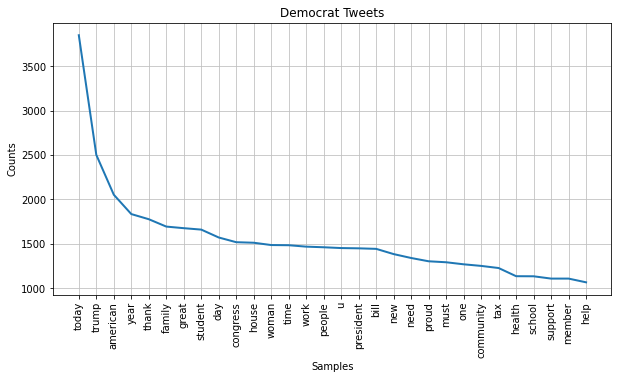

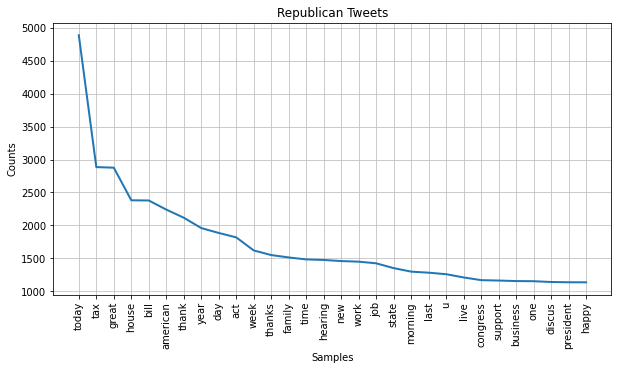

In [240]:
import matplotlib.pyplot as plt
plt.subplots(figsize=(10,5))
fdist_democrat.plot(30,title="Democrat Tweets")
plt.subplots(figsize=(10,5))
fdist_republican.plot(30,title="Republican Tweets")

***Para analisar melhor, mesclo as duas listas e as frequências de palavras usadas no dataframe.***

In [244]:
de=pd.DataFrame(list(fdist_democrat.items()), columns = ["Word","FrequencyDemocrat"])
re=pd.DataFrame(list(fdist_republican.items()), columns = ["Word","FrequencyRepublican"])
nova_base=pd.merge(de,re,on='Word')

In [245]:
nova_base.head(10)

,Word,FrequencyDemocrat,FrequencyRepublican
0,today,3850,4883
1,senate,368,533
2,dems,136,61
3,vote,741,722
4,proud,1303,923
5,support,1108,1166
6,similar,34,15
7,netneutrality,287,4
8,legislation,492,689
9,house,1512,2382


**Também categorizei as frequências de palavras em 5 grupos.**

1. Se uma palavra for usada com menos de 50, ela está no grupo muito baixo.

2. Se for usado entre 50 e 150 vezes, está no grupo baixo.

3. Se for usado entre 150 e 500 vezes, está no grupo médio.

4. Se for usado entre 500 e 1.500 vezes, está no grupo alto.

5. Se o uso de uma palavra for maior que 1.500, ela está no grupo muito alto.

**Também adicionei essas novas listas ao novo dataframe.**

In [251]:
democratclass=[] 
for each in nova_base.FrequencyDemocrat:
    if each<50:
        democratclass.append("Muito baixo")
    elif 49<each<150:
        democratclass.append("Baixo")
    elif 149<each<500:
        democratclass.append("Médio")
    elif 499<each<1500:
        democratclass.append("Alto")
    else:
        democratclass.append("Muito alto")
        
nova_base["democratclass"]=democratclass

In [252]:
republicanclass=[] 
for each in nova_base.FrequencyRepublican:
    if each<50:
        republicanclass.append("Muito baixo")
    elif 49<each<150:
        republicanclass.append("Baixo")
    elif 149<each<500:
        republicanclass.append("Médio")
    elif 499<each<1500:
        republicanclass.append("Alto")
    else:
        republicanclass.append("Muito alto")
        
nova_base["republicanclass"]=republicanclass

In [254]:
nova_base.head(10)

,Word,FrequencyDemocrat,FrequencyRepublican,democratclass,republicanclass
0,today,3850,4883,Muito alto,Muito alto
1,senate,368,533,Médio,Alto
2,dems,136,61,Baixo,Baixo
3,vote,741,722,Alto,Alto
4,proud,1303,923,Alto,Alto
5,support,1108,1166,Alto,Alto
6,similar,34,15,Muito baixo,Muito baixo
7,netneutrality,287,4,Médio,Muito baixo
8,legislation,492,689,Médio,Alto
9,house,1512,2382,Muito alto,Muito alto


In [259]:
democratMuitoAlto=nova_base[nova_base.democratclass=="Muito alto"]
democratAlto=nova_base[nova_base.democratclass=="Alto"]
democratMédio=nova_base[nova_base.democratclass=="Médio"]
democratBaixo=nova_base[nova_base.democratclass=="Baixo"]
democratMuitoBaixo=nova_base[nova_base.democratclass=="Muito baixo"]

In [260]:
vhvh=democratMuitoAlto[nova_base.republicanclass=="Muito alto"]
vhh=democratMuitoAlto[nova_base.republicanclass=="Alto"]
vhm=democratMuitoAlto[nova_base.republicanclass=="Médio"]
vhl=democratMuitoAlto[nova_base.republicanclass=="Baixo"]
vhvl=democratMuitoAlto[nova_base.republicanclass=="Muito baixo"]

hvh=democratAlto[nova_base.republicanclass=="Muito alto"]
hh=democratAlto[nova_base.republicanclass=="Alto"]
hm=democratAlto[nova_base.republicanclass=="Médio"]
hl=democratAlto[nova_base.republicanclass=="Baixo"]
hvl=democratAlto[nova_base.republicanclass=="Muito baixo"]

mvh=democratMédio[nova_base.republicanclass=="Muito alto"]
mh=democratMédio[nova_base.republicanclass=="Alto"]
mm=democratMédio[nova_base.republicanclass=="Médio"]
ml=democratMédio[nova_base.republicanclass=="Baixo"]
mvl=democratMédio[nova_base.republicanclass=="Muito baixo"]

lvh=democratBaixo[nova_base.republicanclass=="Muito alto"]
lh=democratBaixo[nova_base.republicanclass=="Alto"]
lm=democratBaixo[nova_base.republicanclass=="Médio"]
ll=democratBaixo[nova_base.republicanclass=="Baixo"]
lvl=democratBaixo[nova_base.republicanclass=="Muito baixo"]

vlvh=democratMuitoBaixo[nova_base.republicanclass=="Muito alto"]
vlh=democratMuitoBaixo[nova_base.republicanclass=="Alto"]
vlm=democratMuitoBaixo[nova_base.republicanclass=="Médio"]
vll=democratMuitoBaixo[nova_base.republicanclass=="Baixo"]
vlvl=democratMuitoBaixo[nova_base.republicanclass=="Muito baixo"]

**Criação de categorias para criar uma matriz.**

In [263]:
trace5 = go.Scatter(y=vhvh.FrequencyDemocrat, x=vhvh.FrequencyRepublican,text=vhvh.Word,mode='markers+text')
trace4 = go.Scatter(y=vhh.FrequencyDemocrat, x=vhh.FrequencyRepublican,text=vhh.Word,mode='markers+text')
trace3 = go.Scatter(y=vhm.FrequencyDemocrat, x=vhm.FrequencyRepublican,text=vhm.Word,mode='markers+text')
trace2 = go.Scatter(y=vhl.FrequencyDemocrat, x=vhl.FrequencyRepublican,text=vhl.Word,mode='markers+text')
trace1 = go.Scatter(y=vhvl.FrequencyDemocrat, x=vhvl.FrequencyRepublican,text=vhvl.Word,mode='markers+text')

trace10 = go.Scatter(y=hvh.FrequencyDemocrat, x=hvh.FrequencyRepublican,text=hvh.Word,mode='markers+text')
trace9 = go.Scatter(y=hh.FrequencyDemocrat, x=hh.FrequencyRepublican,text=hh.Word,mode='markers+text')
trace8 = go.Scatter(y=hm.FrequencyDemocrat, x=hm.FrequencyRepublican,text=hm.Word,mode='markers+text')
trace7 = go.Scatter(y=hl.FrequencyDemocrat, x=hl.FrequencyRepublican,text=hl.Word,mode='markers+text')
trace6 = go.Scatter(y=hvl.FrequencyDemocrat, x=hvl.FrequencyRepublican,text=hvl.Word,mode='markers+text')

trace15 = go.Scatter(y=mvh.FrequencyDemocrat, x=mvh.FrequencyRepublican,text=mvh.Word,mode='markers+text')
trace14 = go.Scatter(y=mh.FrequencyDemocrat, x=mh.FrequencyRepublican,text=mh.Word,mode='markers+text')
trace13 = go.Scatter(y=mm.FrequencyDemocrat, x=mm.FrequencyRepublican,text=mm.Word,mode='markers+text')
trace12 = go.Scatter(y=ml.FrequencyDemocrat, x=ml.FrequencyRepublican,text=ml.Word,mode='markers+text')
trace11 = go.Scatter(y=mvl.FrequencyDemocrat, x=mvl.FrequencyRepublican,text=mvl.Word,mode='markers+text')


trace20 = go.Scatter(y=lvh.FrequencyDemocrat, x=lvh.FrequencyRepublican,text=lvh.Word,mode='markers+text')
trace19 = go.Scatter(y=lh.FrequencyDemocrat, x=lh.FrequencyRepublican,text=lh.Word,mode='markers+text')
trace18 = go.Scatter(y=lm.FrequencyDemocrat, x=lm.FrequencyRepublican,text=lm.Word,mode='markers+text')
trace17 = go.Scatter(y=ll.FrequencyDemocrat, x=ll.FrequencyRepublican,text=ll.Word,mode='markers+text')
trace16 = go.Scatter(y=lvl.FrequencyDemocrat, x=lvl.FrequencyRepublican,text=lvl.Word,mode='markers+text')

trace25 = go.Scatter(y=vlvh.FrequencyDemocrat, x=vlvh.FrequencyRepublican,text=vlvh.Word,mode='markers+text')
trace24 = go.Scatter(y=vlh.FrequencyDemocrat, x=vlh.FrequencyRepublican,text=vlh.Word,mode='markers+text')
trace23 = go.Scatter(y=vlm.FrequencyDemocrat, x=vlm.FrequencyRepublican,text=vlm.Word,mode='markers+text')
trace22 = go.Scatter(y=vll.FrequencyDemocrat, x=vll.FrequencyRepublican,text=vll.Word,mode='markers+text')
trace21 = go.Scatter(y=vlvl.FrequencyDemocrat, x=vlvl.FrequencyRepublican,text=vlvl.Word,mode='markers+text')

fig = tools.make_subplots(rows=5, cols=5,shared_xaxes=True, shared_yaxes=True,print_grid=False)
#fig = chart_studio.plotly(rows=5, cols=5,shared_xaxes=True, shared_yaxes=True,print_grid=False)

fig.append_trace(trace1, 1, 1)
fig.append_trace(trace2, 1, 2)
fig.append_trace(trace3, 1, 3)
fig.append_trace(trace4, 1, 4)
fig.append_trace(trace5, 1, 5)
fig.append_trace(trace6, 2, 1)
fig.append_trace(trace7, 2, 2)
fig.append_trace(trace8, 2, 3)
fig.append_trace(trace9, 2, 4)
fig.append_trace(trace10, 2, 5)
fig.append_trace(trace11, 3, 1)
fig.append_trace(trace12, 3, 2)
fig.append_trace(trace13, 3, 3)
fig.append_trace(trace14, 3, 4)
fig.append_trace(trace15, 3, 5)
fig.append_trace(trace16, 4, 1)
fig.append_trace(trace17, 4, 2)
fig.append_trace(trace18, 4, 3)
fig.append_trace(trace19, 4, 4)
fig.append_trace(trace20, 4, 5)
fig.append_trace(trace21, 5, 1)
fig.append_trace(trace22, 5, 2)
fig.append_trace(trace23, 5, 3)
fig.append_trace(trace24, 5, 4)
fig.append_trace(trace25, 5, 5)


fig['layout']['xaxis5'].update(title='Muito alto')
fig['layout']['xaxis4'].update(title='Alto')
fig['layout']['xaxis3'].update(title='Médio')
fig['layout']['xaxis2'].update(title='Baixo')
fig['layout']['xaxis1'].update(title='Muito Baixo')

fig['layout']['yaxis1'].update(title='Muito alto')
fig['layout']['yaxis2'].update(title='Alto')
fig['layout']['yaxis3'].update(title='Médio')
fig['layout']['yaxis4'].update(title='Baixo')
fig['layout']['yaxis5'].update(title='Muito Baixo')



fig['layout'].update(height=1500, width=1500, title= "Palavras em tweets democratas e republicanos",showlegend=False, titlefont=dict(size=30),
                    annotations=[dict(showarrow=False,text="Tweets Republicanos",x=0.5,y=-0.06,xref="paper",yref="paper",
                                      font=dict(size=30)),dict(showarrow=False, text='Tweets democrata',
                                                               x=-0.06,y=0.5,xref="paper",yref="paper",textangle=270,
                                                               font=dict(size=30))],
                    plot_bgcolor="snow" ,paper_bgcolor='rgb(243, 243, 243)')

iplot(fig)

**Nesta matriz,**

O eixo x mostra a frequência de uso de palavras de tuítes republicanos e o eixo y democratas.

Por exemplo, a palavra "reforma tributária" é usada pelo republicano 966 vezes (está na categoria alta) (e acho que é uma hashtag). No entanto, os democratas usaram essa palavra apenas 12 vezes.

O outro exemplo é a palavra "arma". É usado 876 vezes em tuítes democratas e 117 vezes em tuítes republicanos.

Também não há palavras, quando os republicanos usaram muito altamente e os democratas usaram no nível médio, baixo ou muito baixo. O mesmo que para os democratas.

As palavras "hoje", "americano", "ótimo," casa "," ano "," família "," dia "e" agradecer "são muito usadas tanto por democratas como republicanos.

Essas categorias são as categorias que criei. Diferentes classificações também podem ser feitas. Os intervalos de uso podem ser alterados.

# **3- Gráficos de Dispersão**

Selecionei algumas palavras no conjunto de dados e observei a distribuição de uso para ambas as partes.

Essas palavras são "voto", "democracia", "liberdade", "américa", "americana", "imposto", "trunfo" e "clinton".

Além disso, as outras palavras podem ser escolhidas.

In [264]:
from nltk.text import Text  
democrat_tweet=Text(democrat_tweets)
republican_tweet=Text(republican_tweets)

Democratas Tweets Plot

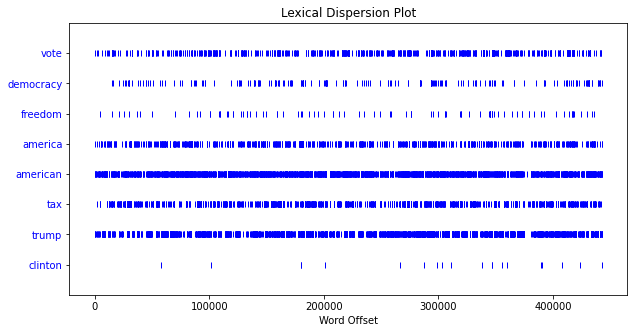

In [265]:
plt.subplots(figsize=(10,5))
democrat_tweet.dispersion_plot(["vote","democracy","freedom","america","american","tax","trump","clinton"])

Republicanos Tweets Plot

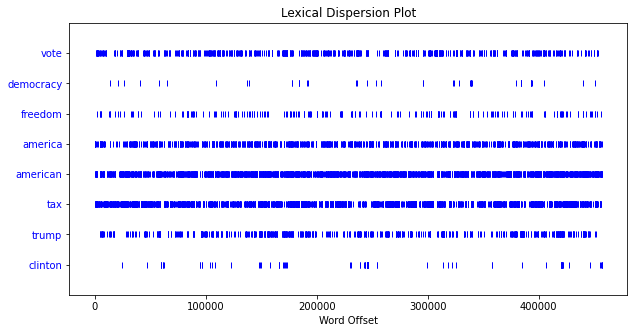

In [266]:
plt.subplots(figsize=(10,5))
republican_tweet.dispersion_plot(["vote","democracy","freedom","america","american","tax","trump","clinton"])

# **4- Análise de sentimentos**

A pontuação de polaridade é uma flutuação dentro do intervalo [-1,0, 1,0]. E representa emoções expressas em uma frase. 1 significa afirmação positiva e -1 significa uma afirmação negativa.

A subjetividade é uma flutuação dentro do intervalo [0,0, 1,0] onde 0,0 é muito objetivo e 1,0 é muito subjetivo. E se refere à opinião pessoal, emoção ou julgamento.

In [267]:
from textblob import TextBlob
democratblob=TextBlob(str(democrat_tweets))
republicanblob=TextBlob(str(republican_tweets))

**Usando o TextBlob, você pode ver as pontuações de polaridade e subjetividade de ambas as partes.**

In [268]:
democratblob.sentiment

Sentiment(polarity=0.16536069955855845, subjectivity=0.4648999095113135)

In [269]:
republicanblob.sentiment

Sentiment(polarity=0.19836825482009132, subjectivity=0.4590716830328091)

# **5- Classificação Naive Bayes**

Carregamos tudo em um Pandas DataFrame. (O conjunto de dados ExtractedTweets.csv consiste nos 200 tweets mais recentes, no momento da coleta de dados, de cada membro da Câmara dos Representantes dos EUA que possui uma conta no Twitter.)

Em seguida, obtemos uma divisão 80/20 dos identificadores do Twitter no conjunto de dados, estratificados de acordo com a variável Party. Dessa forma, teremos proporções aproximadamente semelhantes de democratas e republicanos nos conjuntos de treinamento e teste separadamente, como em todo o conjunto de dados. Por fim, dividimos o conjunto de dados completo em conjuntos de treinamento e teste com base nos identificadores do Twitter, pois não queremos que nenhum tweeter individual apareça nos conjuntos de treinamento e teste.

In [270]:
import pandas as pd 

from nltk.tokenize.casual import TweetTokenizer

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

#inicializar o tokenizer
tokenizer = TweetTokenizer(reduce_len=True)

In [271]:
# Obtenha uma divisão de treinamento / teste de 80/20 dos identificadores do Twitter, estratificados no Party
tweeters = tweets_dem_rep.iloc[:,:2].drop_duplicates()
handles_train, handles_test = train_test_split(tweeters.Handle, stratify=tweeters.Party, test_size=0.2, random_state=0)

# extrair conjuntos de trem e teste de todos os tweets df
train = tweets_dem_rep[tweets_dem_rep.Handle.isin(handles_train)].reset_index().drop('index', axis=1)
test = tweets_dem_rep[tweets_dem_rep.Handle.isin(handles_test)].reset_index().drop('index', axis=1)

### **Construindo pipeline scikit-learn**
Vetorizador TF-IDF e um Classificador. O Vetorizador TF-IDF tokeniza o texto de cada tweet e, em seguida, calcula os pesos TF-IDF para os termos no tweet tokenizado.

In [272]:
nb_pipeline = Pipeline([
    ('vectorize', TfidfVectorizer(tokenizer=tokenizer.tokenize)),
    ('classifier', MultinomialNB())
])

### **Treino e avaliação**
Treinar e avaliar o modelo resulta em 74,34% de precisão por tweet, o que não é tão ruim.

In [273]:
nb_pipeline.fit(train.Tweet, train.Party)

Pipeline(memory=None,
         steps=[('vectorize',
                 TfidfVectorizer(analyzer='word', binary=False,
                                 decode_error='strict',
                                 dtype=<class 'numpy.float64'>,
                                 encoding='utf-8', input='content',
                                 lowercase=True, max_df=1.0, max_features=None,
                                 min_df=1, ngram_range=(1, 1), norm='l2',
                                 preprocessor=None, smooth_idf=True,
                                 stop_words=None, strip_accents=None,
                                 sublinear_tf=False,
                                 token_pattern='(?u)\\b\\w\\w+\\b',
                                 tokenizer=<bound method TweetTokenizer.tokenize of <nltk.tokenize.casual.TweetTokenizer object at 0x7fb745e3d358>>,
                                 use_idf=True, vocabulary=None)),
                ('classifier',
                 MultinomialNB(alpha

In [274]:
preds = nb_pipeline.predict(test.Tweet)
print('Precisão: {}'.format(str(round(accuracy_score(test.Party, preds), 4))))

Precisão: 0.7434


### **Avaliação por congressista**
Não é tão incomum que um único tweet seja mal categorizado, então talvez devêssemos considerar a categorização geral dos tweets de cada congressista. Com este ajuste, obtemos uma precisão de 94,25%, mesmo com este modelo muito simples.

In [275]:
accuracy_df = test.drop(['Tweet'], axis=1)
accuracy_df['preds'] = preds
correct = 0
total = 0

print("Congressistas cujos tweets foram classificados incorretamente:")
for name in accuracy_df.Handle.unique():
    sub_df = accuracy_df[accuracy_df.Handle == name].reset_index()
    sub_preds = sub_df.preds.value_counts()

    if sub_preds.index[0] == sub_df.Party[0]:
        correct += 1
    total += 1

    if sub_preds[sub_df.Party[0]]/len(sub_df) < 0.5:
        print("{} ({}) classificado com precisão: {}".format(name, sub_df.Party[0],
                                                                      str(round(sub_preds[sub_df.Party[0]]/len(sub_df), 4))))

print()
print("A precisão do modelo por congressista foi: {}".format(str(round(correct/total, 4))))

Congressistas cujos tweets foram classificados incorretamente:
Call_Me_Dutch (Democrat) classificado com precisão: 0.49
RepVisclosky (Democrat) classificado com precisão: 0.264
RepSchrader (Democrat) classificado com precisão: 0.495
RepCurbelo (Republican) classificado com precisão: 0.47
DanaRohrabacher (Republican) classificado com precisão: 0.3317

A precisão do modelo por congressista foi: 0.9425
